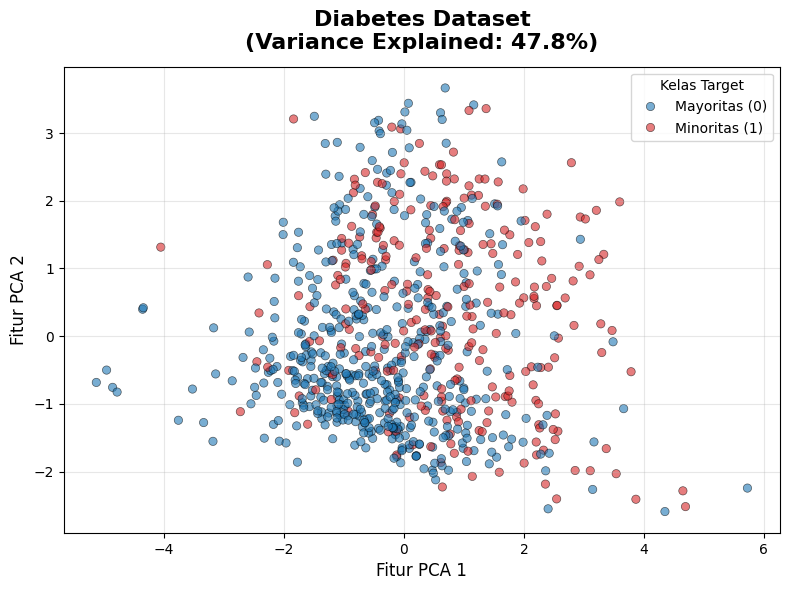

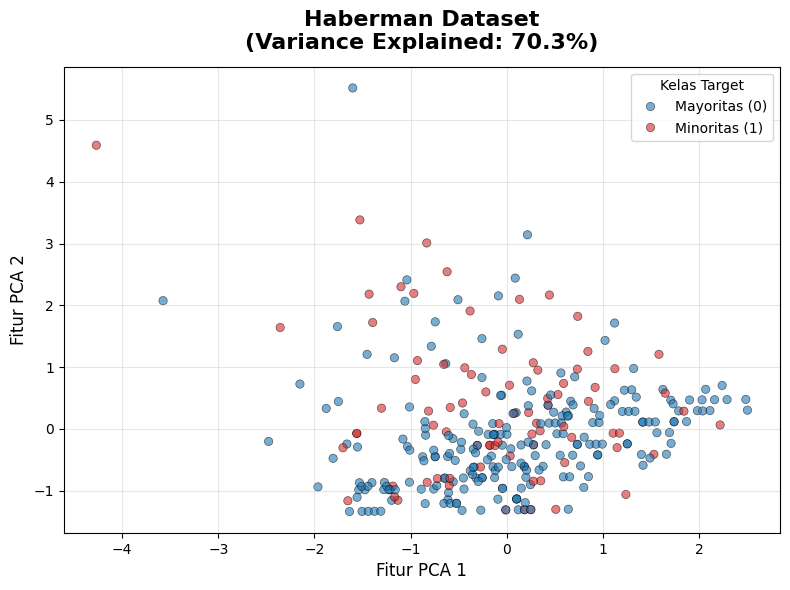

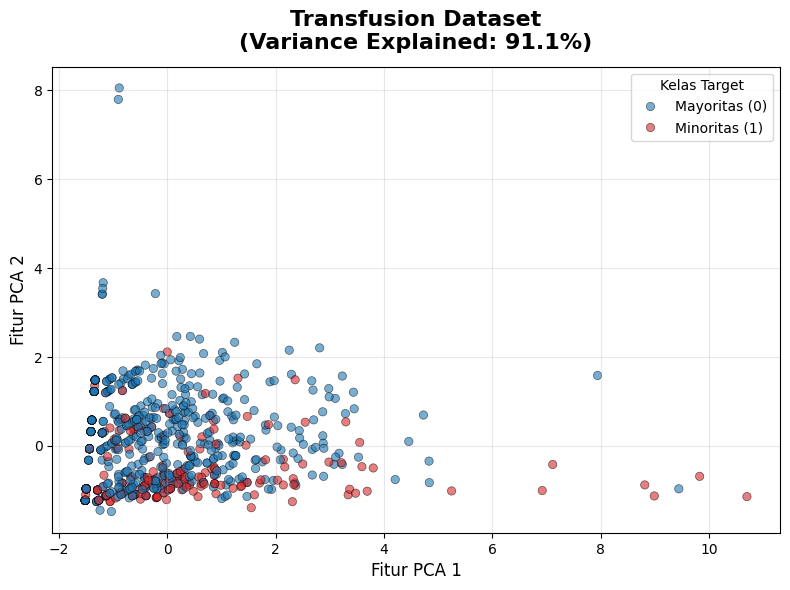

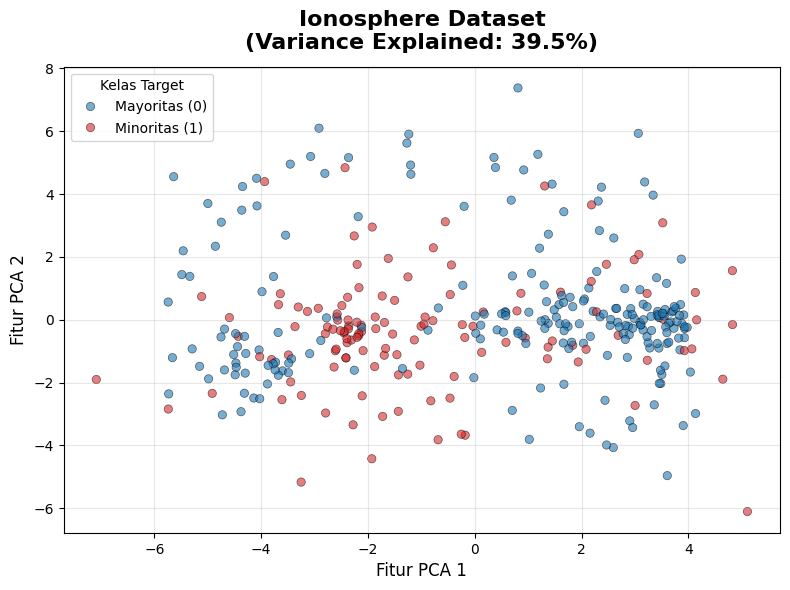

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

# Memasukkan ke-4 dataset
datasets = {
    'Diabetes': 'dataset/diabetes.csv',
    'Haberman': 'dataset/haberman.csv',
    'Transfusion': 'dataset/transfusion.csv',
    'Ionosphere': 'dataset/ionosphere.csv'
}

for name, path in datasets.items():
    if not os.path.exists(path):
        print(f"File tidak ditemukan: {path}")
        continue
    
    df = pd.read_csv(path)
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    
    counts = y.value_counts()
    mayoritas_label = counts.index[0]
    minoritas_label = counts.index[1]
    
    # Menyimpan teks mapping ke dalam variabel agar konsisten
    label_mayoritas = f'Mayoritas ({mayoritas_label})'
    label_minoritas = f'Minoritas ({minoritas_label})'
    
    y = y.map({mayoritas_label: label_mayoritas, minoritas_label: label_minoritas})
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(8, 6))
    
    warna_konsisten = {
        label_mayoritas: '#1f77b4', # Kode Hex Warna Biru
        label_minoritas: '#d62728'  # Kode Hex Warna Merah
    }
    
    sns.scatterplot(
        x=X_pca[:, 0], y=X_pca[:, 1],
        hue=y, 
        hue_order=[label_mayoritas, label_minoritas],
        palette=warna_konsisten,
        alpha=0.6, 
        edgecolor='k'
    )
    
    var_explained = sum(pca.explained_variance_ratio_) * 100
    plt.title(f'{name} Dataset\n(Variance Explained: {var_explained:.1f}%)', fontsize=16, fontweight='bold', y=1.02)
    plt.xlabel('Fitur PCA 1', fontsize=12)
    plt.ylabel('Fitur PCA 2', fontsize=12) 
    plt.legend(title='Kelas Target')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # (Opsional) Uncomment di bawah jika ingin menyimpan gambar sendiri-sendiri
    # img_path = os.path.join(os.getcwd(), "img")
    # os.makedirs(img_path, exist_ok=True)
    # plt.savefig(os.path.join(img_path, f"scatter_pca_{name.lower()}.png"), dpi=150, bbox_inches='tight')

    plt.show()
